In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.linear_model import LassoCV
from sklearn.linear_model import RidgeCV

In [2]:
insurance_data = pd.read_csv("insurance.csv")

In [3]:
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
X = insurance_data.drop(columns=["charges"])  # Features(input)
y = insurance_data["charges"] # Output

In [5]:
#Feature Engineering

X = pd.get_dummies(X, columns=["region"], drop_first=True, dtype=int)
X["sex"] = X["sex"].map({"female":1, "male":0})
X["smoker"] = X["smoker"].map({"yes":0 , "no":1})

X["age_smoker"] = X["age"]*X["smoker"] # Interaction Features (Feature Construction)
X["bmi_smoker"] = X["bmi"]*X["smoker"]

In [6]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)  

In [7]:
# Here we used a random alpha value we don't know this value is correct or not,
# so we use hit and trial method to find at what alpha value our Lasso model performs the best

In [8]:
alphas = [0.001,0.1,1,2,3,4,5,10,20,30,50,100]
mse = []

for a in alphas:
    lasso_model = Lasso(alpha=a) # How much penalty is applied to coefficients
    # alpha is the regularization strength in Lasso regression
    lasso_model.fit(X_train,y_train)

    y_pred = lasso_model.predict(X_test)

    mse.append(mean_squared_error(y_test,y_pred))

In [9]:
mse

[20922599.757902466,
 20921792.853509374,
 20914721.798072886,
 20907674.247202184,
 20901069.21515822,
 20895038.95326912,
 20889582.47940209,
 20870916.229234945,
 20876635.989242192,
 20939746.567615412,
 21213779.567059062,
 22517162.025203776]

<Axes: >

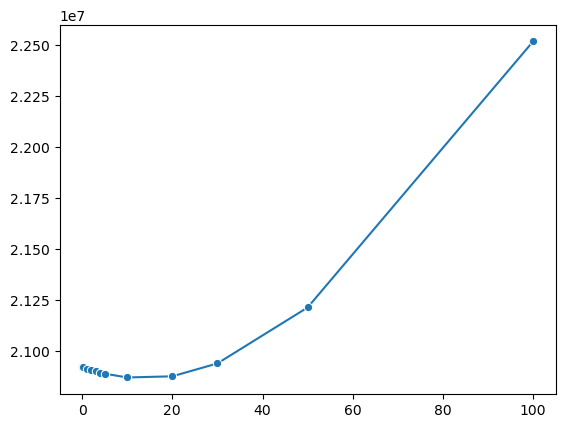

In [10]:
sns.lineplot(x=alphas,y=mse,marker="o")

In [11]:
# Here we can see our alpha value is around 10 which gives the least mse 
# But this is not a right way of finding alpha

In [12]:
# Earlier we were finding the values of alpha by hit and trial method but this is not a good way of finding the value of alpha so we use "LassoCV"
# Using LassoCV means Lasso Regression with Cross-Validation
# LassoCV automatically finds the best value of alpha using cross-validation
a = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]

lasso_cv_model = LassoCV(
    alphas=a,
    cv=5,
    max_iter=1000,
    random_state=42
)

lasso_cv_model.fit(X_train, y_train)

print("best alpha by LassoCV: ", lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("mse = ", mse)
print("r2 = ", r2)

best alpha by LassoCV:  0.001
mse =  20922599.757902466
r2 =  0.865231750643894


In [13]:
# We also have RidgeCV means Ridge Regression with Cross-Validation
# RidgeCV chooses the optimal regularization parameter (alpha) that minimizes validation error and improves generalization
a = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]

ridge_cv_model = RidgeCV(
    alphas=a,
    cv=5,
)

ridge_cv_model.fit(X_train, y_train)

print("best alpha by RidgeCV: ", ridge_cv_model.alpha_)

y_pred = ridge_cv_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("mse = ", mse)
print("r2 = ", r2)

best alpha by RidgeCV:  0.001
mse =  20922417.1776012
r2 =  0.8652329266940911


In [ ]:
# Observation:
# The linear regression model achieved an R² score of about 78% on this dataset
# After applying regularization using LassoCV and RidgeCV, the R² score improved to about 86.5%
# This shows that the regularized models generalize better and provide improved prediction performance compared to the basic linear regression model